<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/nprivaul/coding_trees_v2/blob/master/allen_cahn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
</table>

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # suppress INFO and WARNING
import gc
# install the package if not yet installed
#try:
#    from branch.branch import Net
#except:
#    !python -m pip install git+https://github.com/nguwijy/deep_branching_with_domain.git
#    from branch.branch import Net
import math
import time

import torch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("torch.cuda.is_available=",torch.cuda.is_available())
if torch.cuda.device_count() > 1:
    device0 = torch.device("cuda:0")
    device1 = torch.device("cuda:1")
else:
    device0 = device1 = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

torch.set_default_dtype(torch.float64)

from DeepBSDE2.main import main as deep_bsde

from branch.branch_v2 import Net
from branch.branch_NPP23 import Net_NPP23

# from branch.branch_cv import Net_cv

torch.cuda.is_available= True


2026-03-08 15:08:40.376437: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772953720.437482 2546199 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772953720.454230 2546199 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772953720.589202 2546199 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772953720.589237 2546199 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772953720.589239 2546199 computation_placer.cc:177] computation placer alr

TensorFlow is using: NVIDIA RTX A4000 (GPU 0)


## Allen Cahn Equation

In [2]:
def blow_up_analysis(T_arr, 
                     fixed_dim,
                     dim, 
                     branch_nb_path_per_state, 
                     branch_nb_states_per_batch, 
                     branch_nb_states,
                     branch_exponential_lambda,
                     outlier_percentile,
                     repeats,
                     num_iterations,
                     y_init_range,
                     nu, 
                     xlo, 
                     xhi):

    problem_name = f"allen_cahn_dim_{dim}_time_behavior"

    deriv_map = np.array([0] * dim).reshape(-1, dim)

    mu=1

    def f_example(y, coordinate=0):
        """
        idx 0 -> no deriv
        """
        return mu * ( y[0] - y[0] ** 3 )

    def phi_example(x, coordinate=0):
        scale = torch.sqrt(torch.tensor(x.shape[0], dtype=x.dtype, device=x.device))
        z = x.sum(dim=0) / scale
        z = -0.5 * z
        return -0.5 - 0.5 * torch.tanh(z)

    def exact_example(t, x, T, coordinate=0):
        t = torch.tensor(t, dtype=torch.float32) if not isinstance(t, torch.Tensor) else t
        x = torch.tensor(x, dtype=torch.float32) if not isinstance(x, torch.Tensor) else x
        T = torch.tensor(T, dtype=torch.float32) if not isinstance(T, torch.Tensor) else T
        return -0.5 - 0.5 * torch.tanh(-.5*x.sum(axis=0)/math.sqrt(dim) + 3*(T-t)/4)

    df = []
    for T in T_arr:
#        print(f"Now dealing with T = {T}...")
        # initialize branching model
        torch.manual_seed(0)
        model = Net(
            branch_exponential_lambda=branch_exponential_lambda,
            problem_name=problem_name,
            f_fun2=f_example,
            deriv_map=deriv_map,
            phi_fun=phi_example,
            device=device1,
            x_lo=xlo,
            x_hi=xhi,
            nu=nu,
            T=T,
            outlier_percentile=outlier_percentile,
            epochs=1,
            verbose=True,
            branch_nb_path_per_state=branch_nb_path_per_state,
            branch_nb_states_per_batch=branch_nb_states_per_batch,
            branch_nb_states=branch_nb_states, 
             save_as_tmp=True,
        ).to(device1)

        model_NPP23 = Net_NPP23(
            branch_exponential_lambda=branch_exponential_lambda,
            problem_name=problem_name,
            f_fun=f_example,
            exact_fun_NPP23=exact_example,
            deriv_map=deriv_map,
            phi_fun=phi_example,
            phi_fun_NPP23=phi_example,
            device=device0,
            x_lo=xlo,
            x_hi=xhi,
            nu=nu,
            T=T,
            outlier_percentile=outlier_percentile,
            epochs=1,
            verbose=True,
            branch_nb_path_per_state=branch_nb_path_per_state,
            branch_nb_states_per_batch=branch_nb_states_per_batch,
            branch_nb_states=branch_nb_states, 
            save_as_tmp=True,
        ).to(device0)
        
        tx = torch.zeros(1, dim + 1, device=device1)
        tx[:, -1] = torch.linspace(model.x_lo, model.x_hi, 1)
        
        # branching mc calculation
        start = time.time()
        mc = 0
        for _ in range(repeats):
            x, y = model.gen_sample(patch=0, tx=tx)
            mc += y[:, 0].cpu()
        mc = mc[0].item() / repeats
        mc_time = time.time() - start

        tx=tx.to(device0)
        start = time.time()
        mc_NPP23 = 0
        for _ in range(repeats):
            x, y = model_NPP23.gen_sample(patch=0, tx=tx)
            mc_NPP23 += y[:, 0].cpu()
        mc_NPP23 = mc_NPP23[0].item() / repeats
        mc_NPP23_time = time.time() - start
        
        xz = tx[:, 1:].T.unsqueeze(-1).repeat((1, 1, 1))
        exact = exact_example(t=0, x=xz.cpu(), T=T, coordinate=0)[0].cpu().item()
        start = time.time()
        bsde = deep_bsde(total_time=T, verbose=False, nu=nu, dim=dim, num_iterations=num_iterations, y_init_range=y_init_range)[-1][2]
        bsde_time = time.time() - start
        # exact = 0.61061
        df.append([format(T, ".2f"), format(mc, ".5f"), format(mc_NPP23,".5f"), format(bsde,".5f"), format(exact,".5f"), format(mc_time,".2f"), format(mc_NPP23_time,".2f"), format(bsde_time,".2f")])
        print(problem_name)
        print("dim=",dim)
        print(pd.DataFrame(df, columns=['T', 'branch', 'NPP23', 'bsde', 'exact', 'br-time', 'NPP time', 'bsde time']))

        del model              # remove model object
        del model_NPP23
        gc.collect()           # free Python objects
        torch.cuda.empty_cache()  # release cached GPU memory
    
    # create df & save
    if not os.path.isdir('logs/'):
        os.makedirs('logs/')
    df = pd.DataFrame(df, columns=['T', 'branch', 'NPP23', 'bsde', 'exact', 'br-time', 'NPP time', 'bsde time'])
    df.to_csv("logs/" + problem_name + ".csv")

    grid_1d = np.linspace(0,T,100) 
    x_mid = (xlo + xhi) / 2
    exact = exact_example(0, x_mid * np.ones((fixed_dim, 100)), grid_1d)

    fig, ax = plt.subplots()
    ax.plot(df['T'].astype(float), df['branch'].astype(float), linestyle='-', color='red', label='Binary')
    ax.plot(df['T'].astype(float), df['NPP23'].astype(float), color='blue', label='NPP23')
    ax.plot(df['T'].astype(float), df['exact'].astype(float), color='black', label='Exact',linestyle='--')
    ax.plot(df['T'].astype(float), df['bsde'].astype(float), color='purple', label='BSDE')
    ax.plot(df['T'].astype(float), df['branch'].astype(float), linestyle='None', marker='o', color='red', markerfacecolor='none')
    ax.set_xlabel("T")
    ax.margins(x=0)
    ax.legend(loc="upper right")
    plt.tight_layout()
    ax.grid(True)
    fig.savefig("logs/" + problem_name + ".pdf", bbox_inches="tight")
    # Save df to LaTeX
    df = df.astype(str)
    latex_str = df.to_latex(
        index=False,             
    #    float_format="%.5f",      
        column_format="c"*len(df.columns),  
        caption=None,             
        label=None,               
        bold_rows=False
    )
    with open("logs/" + problem_name + "table.tex", "w") as f:
        f.write(latex_str)    
        
    return df

### Dimension d = 1

In [3]:
T=0.5
delta_t = 0.05
T_arr = np.arange(delta_t, T + delta_t, delta_t)
branch_nb_path_per_state=20000
branch_nb_states_per_batch=10
branch_nb_states=10
branch_exponential_lambda=- 4 * math.log(.95)/T
outlier_percentile=5
repeats=2000
num_iterations=4000
y_init_range=[-1,0]
xlo=0.0
xhi=0.0
nu=1.0

Logs are saved in /home/nprivault/NTU/huang_qiao/PDEs/coding_trees_v2/logs/tmp
Begin to solve Allen-Cahn3 
I0000 00:00:1772953786.563462 2546199 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 11484 MB memory:  -> device: 0, name: NVIDIA RTX A4000, pci bus id: 0000:21:00.0, compute capability: 8.6


allen_cahn_dim_1_time_behavior
dim= 1
      T    branch     NPP23      bsde     exact br-time NPP time bsde time
0  0.05  -0.51842  -0.51873  -0.51875  -0.51874   32.05    30.93    241.79


Logs are saved in /home/nprivault/NTU/huang_qiao/PDEs/coding_trees_v2/logs/tmp
Begin to solve Allen-Cahn3 


allen_cahn_dim_1_time_behavior
dim= 1
      T    branch     NPP23      bsde     exact br-time NPP time bsde time
0  0.05  -0.51842  -0.51873  -0.51875  -0.51874   32.05    30.93    241.79
1  0.10  -0.53767  -0.53744  -0.53747  -0.53743   41.55    44.20    229.27


Logs are saved in /home/nprivault/NTU/huang_qiao/PDEs/coding_trees_v2/logs/tmp
Begin to solve Allen-Cahn3 


...

allen_cahn_dim_1_time_behavior
dim= 1
      T    branch     NPP23      bsde     exact br-time NPP time bsde time
0  0.05  -0.51842  -0.51873  -0.51875  -0.51874   32.05    30.93    241.79
1  0.10  -0.53767  -0.53744  -0.53747  -0.53743   41.55    44.20    229.27
2  0.15  -0.55464  -0.55603  -0.55606  -0.55601   47.10    53.40    230.72
3  0.20  -0.57162  -0.57449  -0.57453  -0.57444   59.41    72.89    229.94
4  0.25  -0.59134  -0.59271  -0.59290  -0.59267   82.72    97.70    236.88
5  0.30  -0.60703  -0.61064  -0.61092  -0.61064  116.99   137.16    232.98
6  0.35  -0.62471  -0.62822  -0.62894  -0.62832  122.22   145.63    238.96
7  0.40  -0.64061  -0.64567  -0.64597  -0.64566  140.68   165.44    229.67


Logs are saved in /home/nprivault/NTU/huang_qiao/PDEs/coding_trees_v2/logs/tmp
Begin to solve Allen-Cahn3 


allen_cahn_dim_1_time_behavior
dim= 1
      T    branch     NPP23      bsde     exact br-time NPP time bsde time
0  0.05  -0.51842  -0.51873  -0.51875  -0.51874   32.05    30.93    241.79
1  0.10  -0.53767  -0.53744  -0.53747  -0.53743   41.55    44.20    229.27
2  0.15  -0.55464  -0.55603  -0.55606  -0.55601   47.10    53.40    230.72
3  0.20  -0.57162  -0.57449  -0.57453  -0.57444   59.41    72.89    229.94
4  0.25  -0.59134  -0.59271  -0.59290  -0.59267   82.72    97.70    236.88
5  0.30  -0.60703  -0.61064  -0.61092  -0.61064  116.99   137.16    232.98
6  0.35  -0.62471  -0.62822  -0.62894  -0.62832  122.22   145.63    238.96
7  0.40  -0.64061  -0.64567  -0.64597  -0.64566  140.68   165.44    229.67
8  0.45  -0.65912  -0.66218  -0.92878  -0.66262  159.65   188.95    234.04


Logs are saved in /home/nprivault/NTU/huang_qiao/PDEs/coding_trees_v2/logs/tmp
Begin to solve Allen-Cahn3 


allen_cahn_dim_1_time_behavior
dim= 1
      T    branch     NPP23      bsde     exact br-time NPP time bsde time
0  0.05  -0.51842  -0.51873  -0.51875  -0.51874   32.05    30.93    241.79
1  0.10  -0.53767  -0.53744  -0.53747  -0.53743   41.55    44.20    229.27
2  0.15  -0.55464  -0.55603  -0.55606  -0.55601   47.10    53.40    230.72
3  0.20  -0.57162  -0.57449  -0.57453  -0.57444   59.41    72.89    229.94
4  0.25  -0.59134  -0.59271  -0.59290  -0.59267   82.72    97.70    236.88
5  0.30  -0.60703  -0.61064  -0.61092  -0.61064  116.99   137.16    232.98
6  0.35  -0.62471  -0.62822  -0.62894  -0.62832  122.22   145.63    238.96
7  0.40  -0.64061  -0.64567  -0.64597  -0.64566  140.68   165.44    229.67
8  0.45  -0.65912  -0.66218  -0.92878  -0.66262  159.65   188.95    234.04
9  0.50  -0.67349  -0.67871  -0.58457  -0.67918  200.95   210.98    241.17


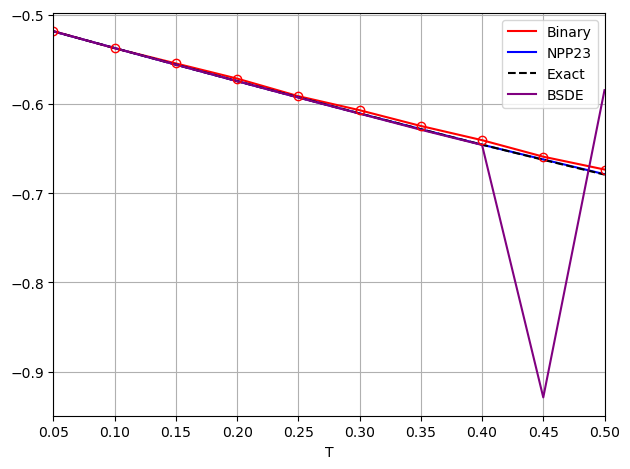

In [4]:
df = blow_up_analysis(
    T_arr=T_arr,
    fixed_dim=0,
    dim=1,
    branch_nb_path_per_state=branch_nb_path_per_state, 
    branch_nb_states_per_batch=branch_nb_states_per_batch,
    branch_nb_states=branch_nb_states,
    branch_exponential_lambda=branch_exponential_lambda,
    outlier_percentile=outlier_percentile,
    repeats=repeats,
    nu=nu,
    num_iterations=num_iterations,
    y_init_range=y_init_range,
    xlo=xlo,
    xhi=xhi
)

### Dimension d = 10

In [ ]:
repeats=500

In [ ]:
df = blow_up_analysis(
    T_arr=T_arr,
    fixed_dim=0,
    dim=10,
    branch_nb_path_per_state=branch_nb_path_per_state, 
    branch_nb_states_per_batch=branch_nb_states_per_batch,
    branch_nb_states=branch_nb_states,
    branch_exponential_lambda=branch_exponential_lambda,
    outlier_percentile=outlier_percentile,
    repeats=repeats,
    nu=nu,
    num_iterations=num_iterations,
    y_init_range=y_init_range,
    xlo=xlo,
    xhi=xhi
)

### Dimension d = 100

In [ ]:
repeats=100

In [ ]:
df = blow_up_analysis(
    T_arr=T_arr,
    fixed_dim=0,
    dim=100,
    branch_nb_path_per_state=branch_nb_path_per_state, 
    branch_nb_states_per_batch=branch_nb_states_per_batch,
    branch_nb_states=branch_nb_states,
    branch_exponential_lambda=branch_exponential_lambda,
    outlier_percentile=outlier_percentile,
    repeats=repeats,
    nu=nu,
    num_iterations=num_iterations,
    y_init_range=y_init_range,
    xlo=xlo,
    xhi=xhi
)

### Dimension d = 1000

In [ ]:
repeats=6

In [ ]:
df = blow_up_analysis(
    T_arr=T_arr,
    fixed_dim=0,
    dim=1000,
    branch_nb_path_per_state=branch_nb_path_per_state, 
    branch_nb_states_per_batch=branch_nb_states_per_batch,
    branch_nb_states=branch_nb_states,
    branch_exponential_lambda=branch_exponential_lambda,
    outlier_percentile=outlier_percentile,
    repeats=repeats,
    nu=nu,
    num_iterations=num_iterations,
    y_init_range=y_init_range,
    xlo=xlo,
    xhi=xhi
)